## 1. Import Libraries & modules

In [35]:
import itertools
import os

# Scikit-learn modules
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder 

# Data processing libraries
import numpy as np
import pandas as pd
import preprocess           # Preprocess.py 

# Plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 3 different algorithms
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier

## 2. Import & Explore Data

In [2]:
df = pd.read_csv("malicious_url.csv")

print("Dataframe shape: ", df.shape, "\n")
print("Types or url: ", df.type.value_counts())

df.head()

Dataframe shape:  (651191, 2) 

Types or url:  type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


**Plotting Wordcloud**

In [3]:
def generate_wordCloud(df):
    url = ' '.join(i for i in df.url)
    wordcloud = WordCloud(width=1000, height=500, colormap='Paired').generate(url)
    plt.figure(figsize=(8, 5), facecolor='k')
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

In [4]:
# Create dataframes for each type of URL
df_benign = df[df.type == 'benign']
df_defacement = df[df.type == 'defacement']
df_phishing = df[df.type == 'phishing']
df_malware = df[df.type == 'malware']

WordCloud for Benign url


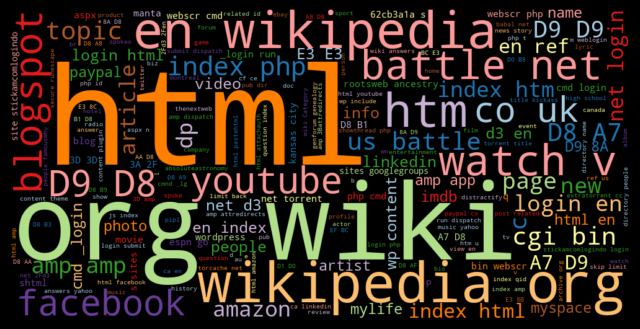

WordCloud for Defacement url


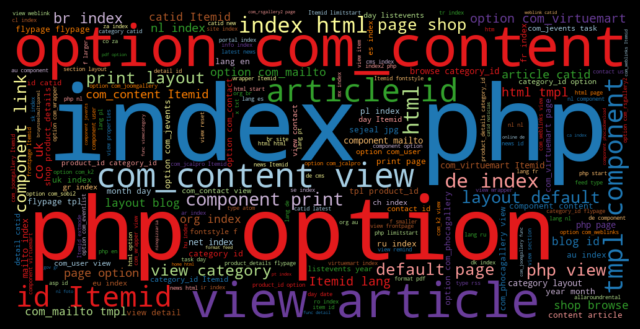

WordCloud for Phishing url


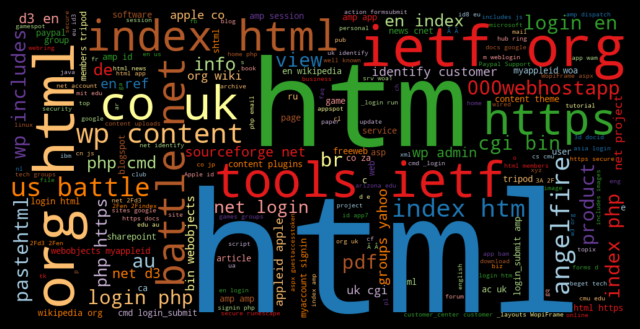

WordCloud for Malware url


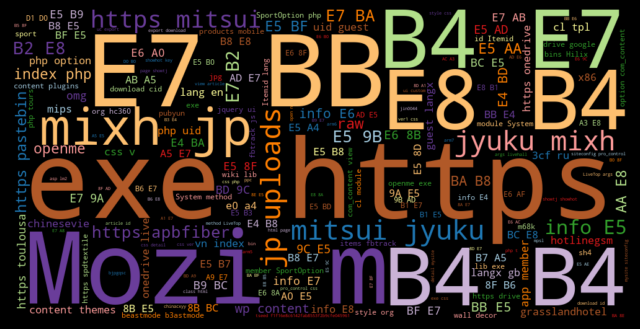

In [26]:
# WordCloud for benign
print('WordCloud for Benign url')
generate_wordCloud(df_benign)

print('WordCloud for Defacement url')
generate_wordCloud(df_defacement)

print('WordCloud for Phishing url')
generate_wordCloud(df_phishing)

print('WordCloud for Malware url')
generate_wordCloud(df_malware)

**Feature Engineering**

In [21]:
df['type'].value_counts()

type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

### 1. Distribution of Binary columns

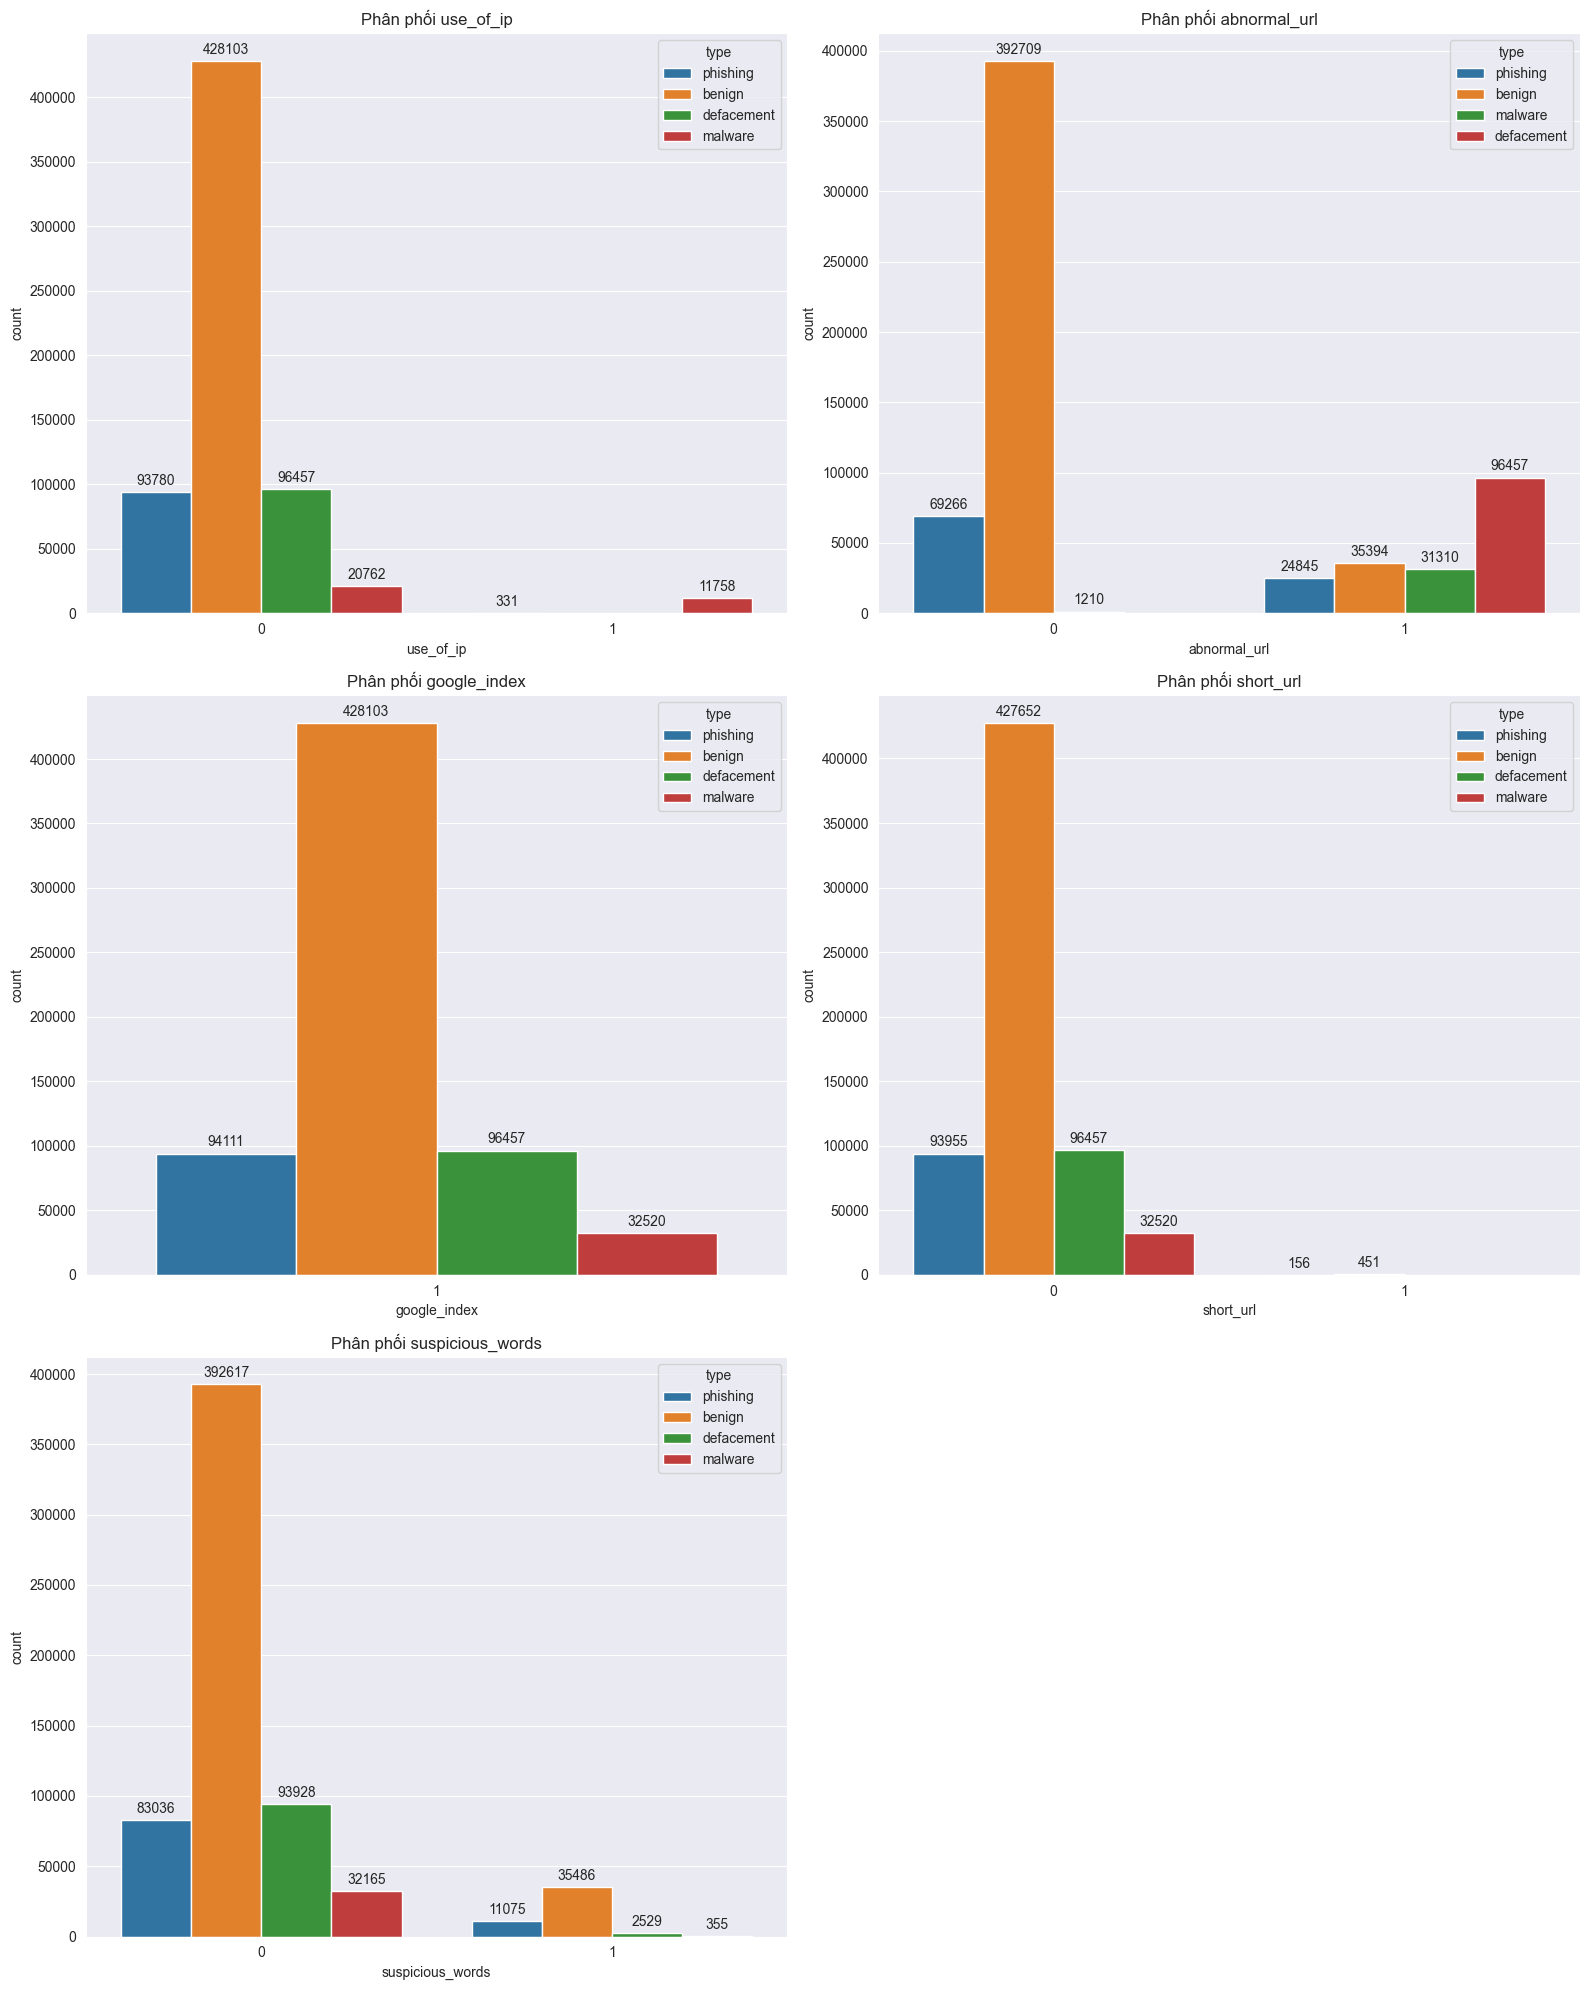

In [22]:
# Danh sách tất cả các cột binary (0/1) bạn muốn vẽ
# Thay đổi list này theo các cột trong dataframe của bạn
binary_cols = [
    'use_of_ip',
    'abnormal_url',
    'google_index',
    'short_url',          # URL rút gọn
    'suspicious_words'   # Có từ đáng ngờ
]

# Thiết lập style
sns.set_style('darkgrid')

# Binary
plt.figure(figsize=(16, 20))
for i, col in enumerate(binary_cols, 1):
    ax = plt.subplot(3, 2, i)
    sns.countplot(data=df, x=col, hue='type', ax=ax)
    plt.title(f'Phân phối {col}')
    for container in ax.containers:
        ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()



### 2. Distribution of Continuous columns

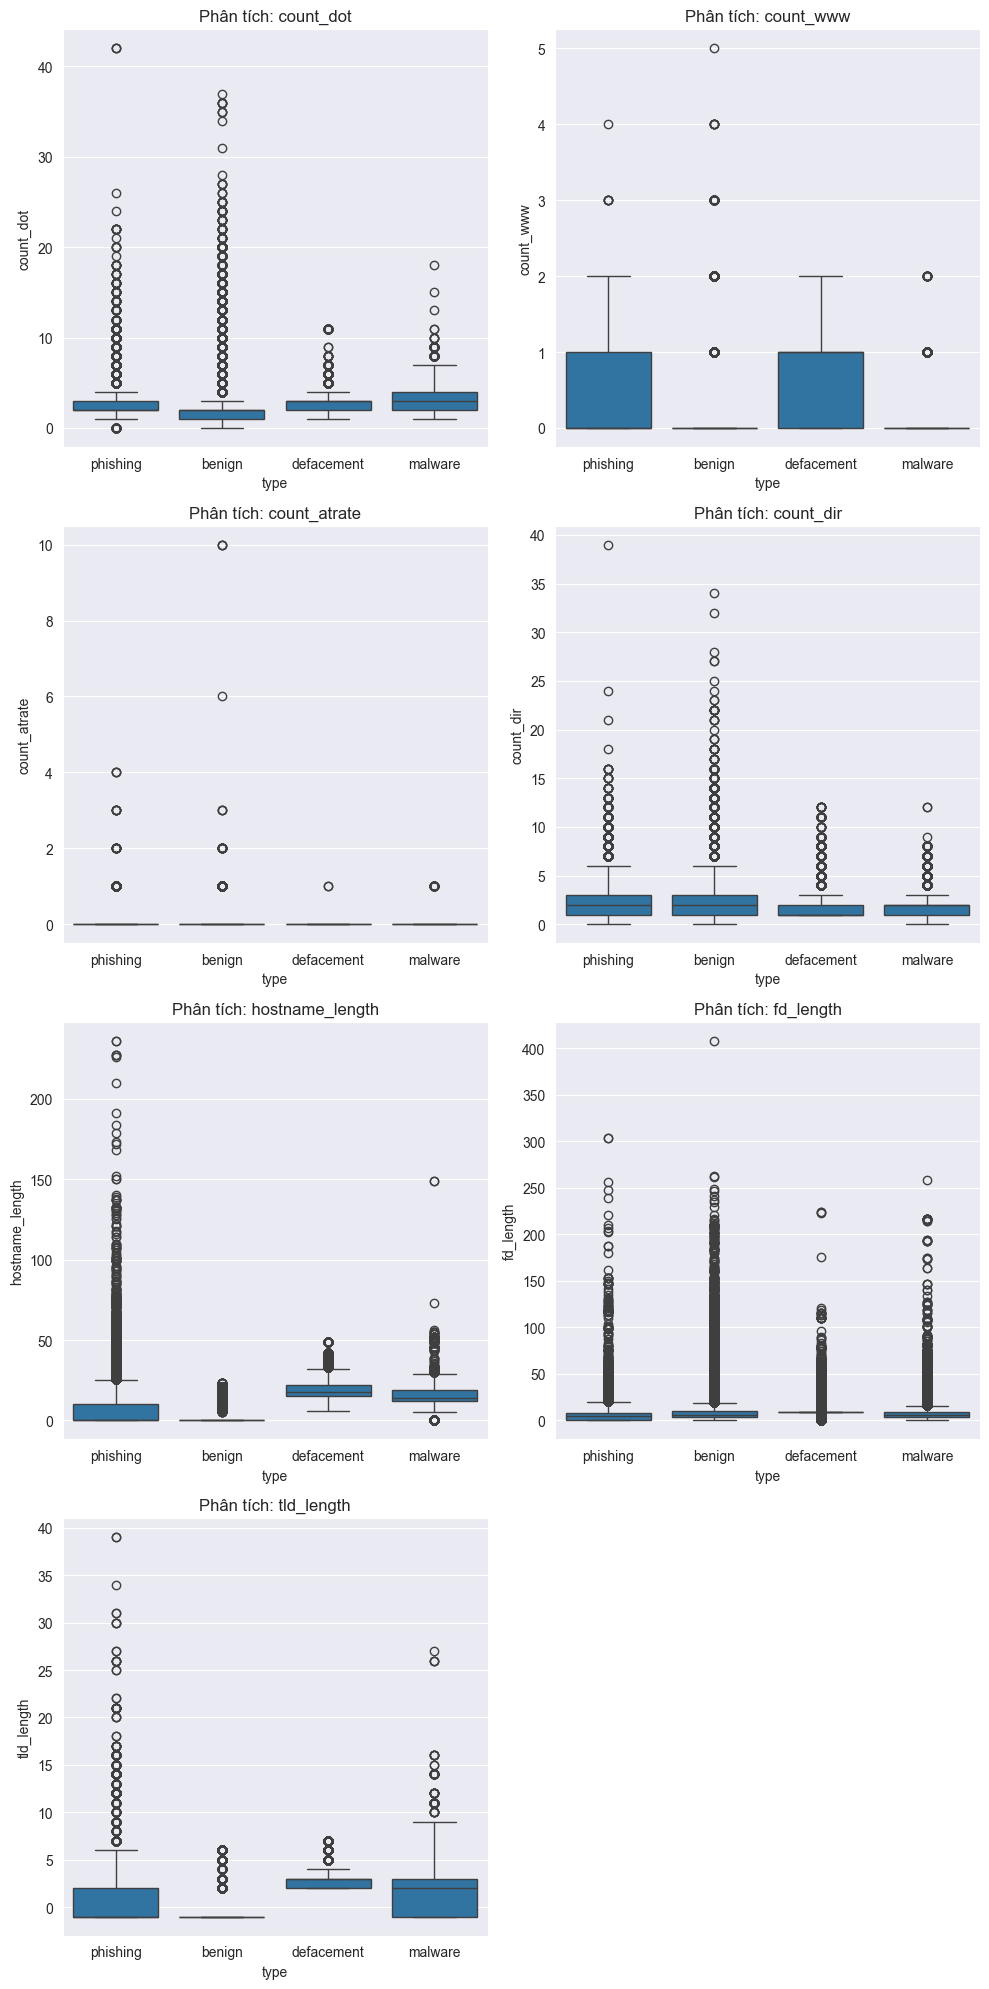

In [23]:
continuous_cols = [
    'count_dot',
    'count_www',
    'count_atrate',
    'count_dir',
    'hostname_length',
    'fd_length',
    'tld_length'
]

plt.figure(figsize=(10, 20))
for i, col in enumerate(continuous_cols, 1):
    ax = plt.subplot(4, 2, i)
    # Vẽ boxplot
    sns.boxplot(data=df, x='type', y=col, ax=ax)
    plt.title(f'Phân tích: {col}')

plt.tight_layout()
plt.show()

### Encoding the Target

In [36]:
lb_make = LabelEncoder()
df['type_code'] = lb_make.fit_transform(df['type'])
df['type_code'].value_counts()

type_code
0    428103
1     96457
3     94111
2     32520
Name: count, dtype: int64

### Create Features and Target

In [38]:
# 2. Áp dụng hàm tổng hợp cho toàn bộ cột 'url'
# Hàm .apply(fe.extract_all_features) sẽ trả về một Series các Dictionary
# .tolist() và pd.DataFrame sẽ biến nó thành một bảng dữ liệu số hoàn chỉnh
X = pd.DataFrame(df['url'].apply(preprocess.extract_all_features).tolist())

# 3. Lấy cột kết quả (Target)
Y = df['type'] # Hoặc 'result' tùy tên cột trong dataset của ông

pd.set_option('display.max_columns', None)

# Kiểm tra thử 5 dòng đầu tiên
X.head()

,have_ip,abnormal_url,google_index,count_dot,count_www,count_atrate,count_dir,count_embed_domain,short_url,count_https,count_http,count_percent,count_question,count_hyphen,count_equal,url_length,hostname_length,suspicious_word,count_letter,count_digit,fd_length,tld_length
0,0,1,1,2,0,0,0,0,0,0,0,0,0,1,0,16,0,0,13,0,0,0
1,0,1,1,2,0,0,2,0,0,0,0,0,0,0,0,35,0,0,29,1,5,0
2,0,1,1,2,0,0,3,0,0,0,0,0,0,0,0,31,0,0,25,1,7,0
3,0,1,1,3,1,0,1,0,0,0,1,0,1,1,4,88,21,0,63,7,9,2
4,0,1,1,2,0,0,1,0,0,0,1,0,1,1,3,235,23,0,199,22,9,3


**Train Test Split**

In [39]:
x_train, y_train, x_test, x_test = train_test_split(X, Y, stratify=Y, test_size=0.2, shuffle=True, random_state=5)

# Model Bulding

## 1. Random Forest Classifier